<a href="https://colab.research.google.com/github/shreyas284-crtl/Data-Science-Internship/blob/main/class5_Linear_regression_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Health Insurance Price Prediction**

### **Problem Statement**

The goal of this project is to develop a **predictive model** that accurately estimates the **medical insurance costs** for individuals based on various **demographic, lifestyle, and health-related factors**. By applying **machine learning techniques**, we aim to assist **insurance companies** in better understanding their risk profiles and help **individuals gain insights** into how different factors influence their **insurance premiums**.

### **Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

##**Load Data**

In [ ]:
data = pd.read_csv('insurance.csv')
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


**Domain Analysis**
The descriptions of the variables based on the insurance dataset:

1. **Age**
   - **Description:** Age of the primary beneficiary covered by health insurance.
   - **Type:** Continuous numerical variable.

2. **Sex**
   - **Description:** Gender of the insurance contractor.
   - **Type:** Categorical variable with two levels: female, male.

3. **BMI (Body Mass Index)**
   - **Description:** Body mass index, which is a measure of body fat based on height and weight.
   - **Type:** Continuous numerical variable.
   - **Ideal Range:** Ideally between 18.5 to 24.9 kg/m².

4. **Children**
   - **Description:** Number of children covered by health insurance or number of dependents.
   - **Type:** Discrete numerical variable.

5. **Smoker**
   - **Description:** Binary indicator if the beneficiary is a smoker.
   - **Type:** Categorical variable with two levels: yes, no.

6. **Region**
   - **Description:** The beneficiary's residential area in the US.
   - **Type:** Categorical variable with four levels: northeast, southeast, southwest, northwest.

7. **Charges**
   - **Description:** Individual medical costs billed by health insurance.
   - **Type:** Continuous numerical variable.

### **Basic Checks**

In [ ]:
# shape : gives number of rows and columns
data.shape

(1338, 7)

There are 1338 rows and 7 columns.

In [ ]:
# head: print first 5 rows
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# tail : print last 5 rows
data.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [ ]:
# info: memory usage
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
# print all columns
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [ ]:
# check the data type
data.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [ ]:
# print numerical columns
num_col= data.select_dtypes(include=['int64','float64'])
num_col


,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520
...,...,...,...,...
1333,50,30.970,3,10600.54830
1334,18,31.920,0,2205.98080
1335,18,36.850,0,1629.83350
1336,21,25.800,0,2007.94500


In [ ]:
# print categorical columns
cat_col= data.select_dtypes(include=['object'])
cat_col

,sex,smoker,region
0,female,yes,southwest
1,male,no,southeast
2,male,no,southeast
3,male,no,northwest
4,male,no,northwest
...,...,...,...
1333,male,no,northwest
1334,female,no,northeast
1335,female,no,southeast
1336,female,no,southwest


In [ ]:
# statiscal report for numerical column
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
# statiscal report for categorical column
data.describe(include='object')

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


In [ ]:
# find unique values in categorical column
for x in cat_col:
  print(x,'-->',data[x].unique())

sex --> ['female' 'male']
smoker --> ['yes' 'no']
region --> ['southwest' 'southeast' 'northwest' 'northeast']


In [ ]:
# find value counts
for x in cat_col:
  print(data[x].value_counts())
  print()

sex
male      676
female    662
Name: count, dtype: int64

smoker
no     1064
yes     274
Name: count, dtype: int64

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64



### **Data Cleaning**

**Check for Misisng values**

In [ ]:
data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


Clearly no missing values.

**Check for duplicates**

In [ ]:
# duplicates : repeated values
data.duplicated().sum()

np.int64(1)

There is 1 duplicate which has to be dropped.

In [ ]:
# drop duplicates
data.drop_duplicates(inplace=True)

In [ ]:
data.duplicated().sum()

np.int64(0)

## **Exploratory Data Analysis**

###**Univariate Analysis**
Analysing single column
* Histogram
* countplot
* box plot

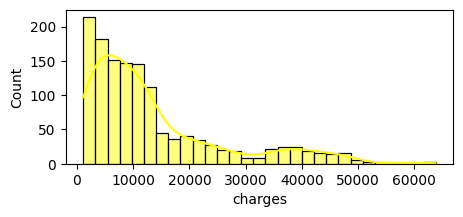

In [ ]:
# Check the distribution of charges
plt.figure(figsize=(5,2))
sns.histplot(data,x='charges',kde=True,color='yellow')
plt.show()

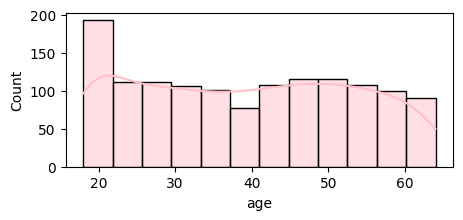

In [ ]:
# Check the distribution of age
plt.figure(figsize=(5,2))
sns.histplot(data,x='age',kde=True,color='pink')
plt.show()

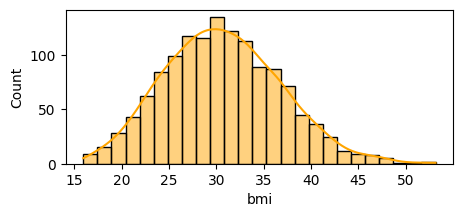

In [ ]:
#Check the distribution of bmi
plt.figure(figsize=(5,2))
sns.histplot(data,x='bmi',kde=True,color='orange')
plt.show()

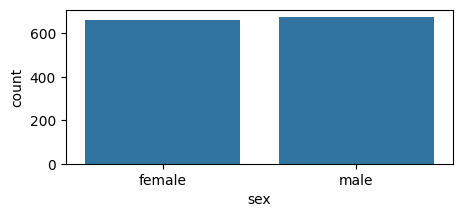

In [ ]:
# Visualise count of male and female
plt.figure(figsize=(5,2))
sns.countplot(data , x='sex')
plt.show()

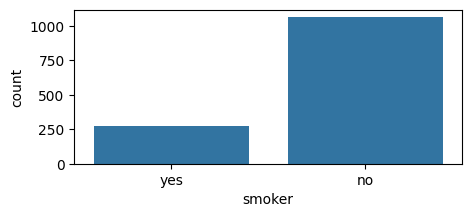

In [ ]:
# Visualise count of smokers and non smokers
plt.figure(figsize=(5,2))
sns.countplot(data , x='smoker')
plt.show()

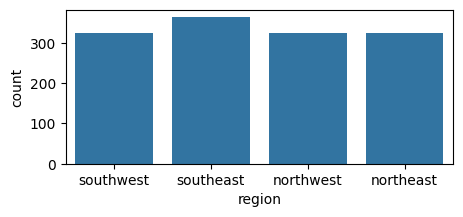

In [ ]:
# Visualise count of different region
plt.figure(figsize=(5,2))
sns.countplot(data , x='region')
plt.show()

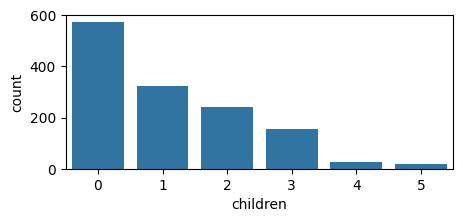

In [ ]:
# count of children
plt.figure(figsize=(5,2))
sns.countplot(data , x='children')
plt.show()

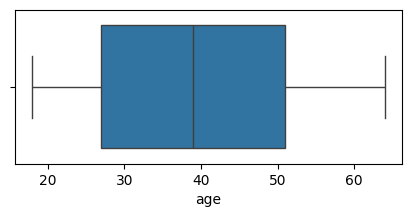

In [ ]:
# check are there any outliers in age
plt.figure(figsize=(5,2))
sns.boxplot(data,x='age')
plt.show()

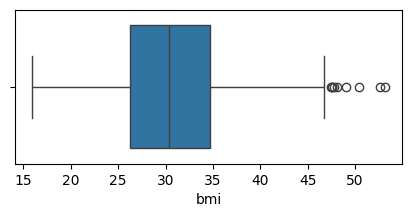

In [ ]:
# check are there any outliers in bmi
plt.figure(figsize=(5,2))
sns.boxplot(data,x='bmi')
plt.show()

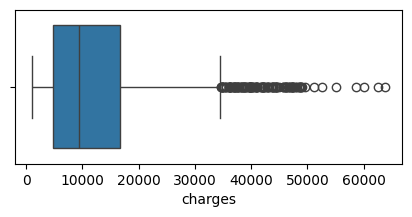

In [ ]:
# # check are there any outliers in charges
plt.figure(figsize=(5,2))
sns.boxplot(data,x='charges')
plt.show()

In [ ]:
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


###**Bivariate Analysis**
Analysing two variables/columns
1. scatter
2. bar plot
3. line plot

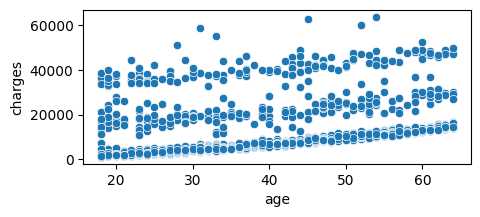

In [ ]:
# find relationship between age and charges
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='age',y='charges')
plt.show()


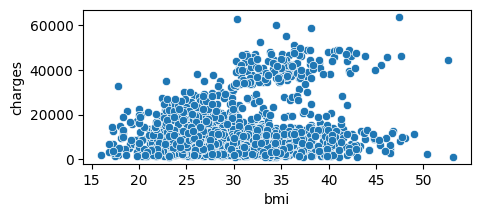

In [ ]:
# find relationship between bmi and charges
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='bmi',y='charges')
plt.show()

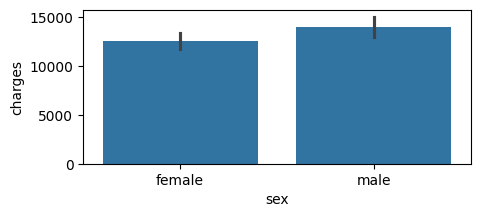

In [ ]:
# find how charges vary with gender
plt.figure(figsize=(5,2))
sns.barplot(data,x='sex',y='charges')
plt.show()

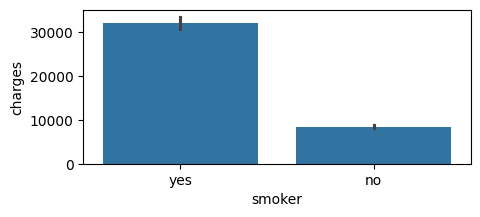

In [ ]:
# find how charges vary with smokers
# find how charges vary with gender
plt.figure(figsize=(5,2))
sns.barplot(data,x='smoker',y='charges')
plt.show()

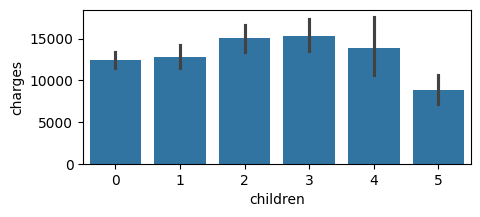

In [ ]:
# find how charges  vary with children
# find how charges vary with gender
plt.figure(figsize=(5,2))
sns.barplot(data,x='children',y='charges')
plt.show()

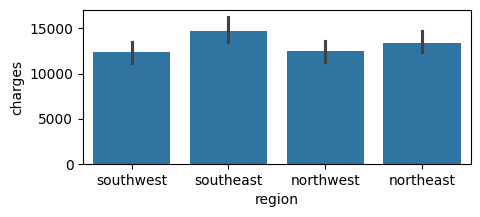

In [ ]:
# find how charges vary with region
# find how charges vary with gender
plt.figure(figsize=(5,2))
sns.barplot(data,x='region',y='charges')
plt.show()

In [ ]:
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


###**Multivariate Analysis**

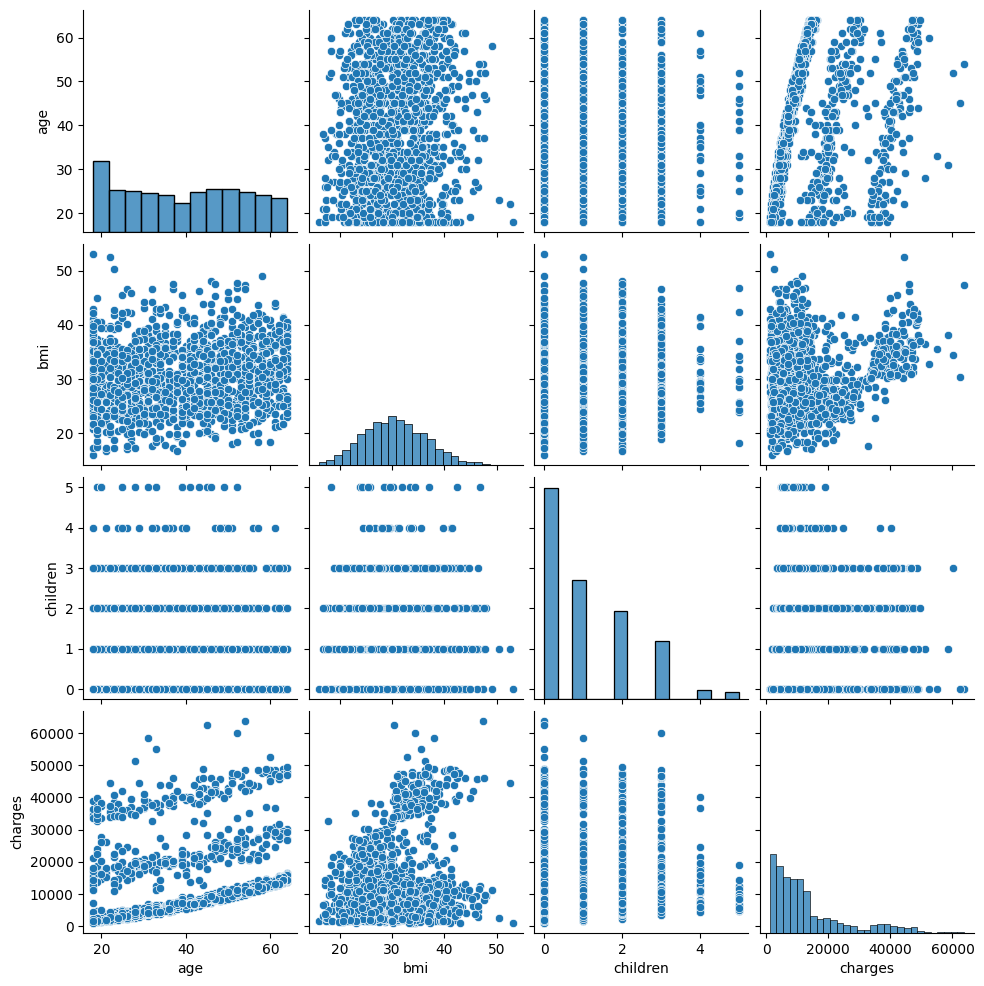

In [ ]:
# pairplot
sns.pairplot(data)

In [ ]:
# heat map
corr = num_col.corr()
corr

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


<Axes: >

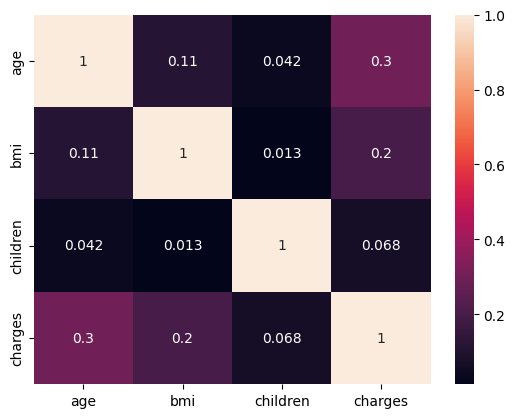

In [ ]:
sns.heatmap(num_col.corr(),annot=True)

## **Handling Outliers**

Outliers are extreme values which are far away actual data.

Eg: Age of students:[20,22,23,24,25,40,98,100,160]

In this case 98,100,160 are outliers

**How to Check outliers**
- boxplot : Tells about the existence and direction of outliers
- scatter plot
- histogram


**How to find Outliers**
- IQR (Interquartile range) : Used when data distribution is skewed.
- 3-sigma rule : Used when distribution is normal
- Outliers can be handled only if % of outliers is very less or less than 5%.

### **IQR**

IQR Should be used when data distribution is skewed.
1. Find Q1
2. Find Q3
3. Find IQR = Q3-Q1
4. Find lower_limit = Q1-1.5*IQR
5. Find upper limit = Q3+1.5*IQR
6. Any value which is greater than upper limit and less than lower limit is considered as **outlier**.

**Check outliers in numerical columns**

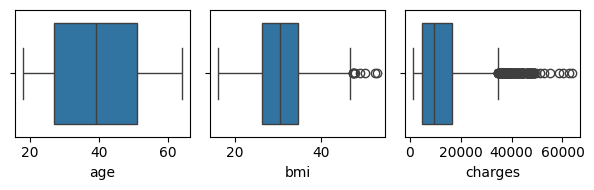

In [ ]:
fig,ax=plt.subplots(1,3,figsize=(6,2))
sns.boxplot(data,x='age',ax=ax[0])
sns.boxplot(data,x='bmi',ax=ax[1])
sns.boxplot(data,x='charges',ax=ax[2])
plt.tight_layout()

Clearly it shows that bmi and charges have outliers towards right.

**Check the distribution of bmi and charges**

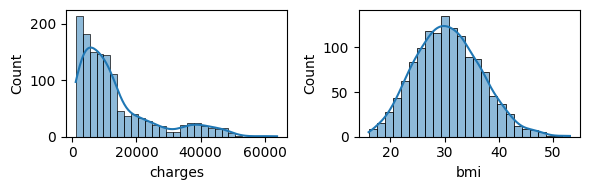

In [ ]:
fig,ax=plt.subplots(1,2,figsize=(6,2))
sns.histplot(data,x='charges',ax=ax[0],kde=True)
sns.histplot(data,x='bmi',ax=ax[1],kde=True)
plt.tight_layout()

In [ ]:
# skewness of bmi and charges
data.loc[:,'bmi'].skew()
# bmi distribution is normal

np.float64(0.28391419385321137)

In [ ]:
data.loc[:,'charges'].skew()
# charges distribution is skewed

np.float64(1.5153909108403483)

**IQR methods for Charges**

Since distribution is skewed

In [ ]:
Q1 = data.loc[:,'charges'].quantile(0.25)
Q3 = data.loc[:,'charges'].quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [ ]:
# filter values greater than upper_limit
data[data.loc[:,'charges']>upper_limit]

,age,sex,bmi,children,smoker,region,charges
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
23,34,female,31.920,1,yes,northeast,37701.87680
29,31,male,36.300,2,yes,southwest,38711.00000
30,22,male,35.600,0,yes,southwest,35585.57600
...,...,...,...,...,...,...,...
1300,45,male,30.360,0,yes,southeast,62592.87309
1301,62,male,30.875,3,yes,northwest,46718.16325
1303,43,male,27.800,0,yes,southwest,37829.72420
1313,19,female,34.700,2,yes,southwest,36397.57600


In [ ]:
# filter values less than lower_limit
data[data.loc[:,'charges']<lower_limit]

,age,sex,bmi,children,smoker,region,charges


In [ ]:
# filter values greater than upper limit , less than lower limit
data[(data.loc[:,'charges']>upper_limit) | (data.loc[:,'charges']<lower_limit)]

,age,sex,bmi,children,smoker,region,charges
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
23,34,female,31.920,1,yes,northeast,37701.87680
29,31,male,36.300,2,yes,southwest,38711.00000
30,22,male,35.600,0,yes,southwest,35585.57600
...,...,...,...,...,...,...,...
1300,45,male,30.360,0,yes,southeast,62592.87309
1301,62,male,30.875,3,yes,northwest,46718.16325
1303,43,male,27.800,0,yes,southwest,37829.72420
1313,19,female,34.700,2,yes,southwest,36397.57600


In [ ]:
# percentage
len(data[(data.loc[:,'charges']>upper_limit) | (data.loc[:,'charges']<lower_limit)])/len(data)*100

10.396409872849663

Since % of outliers are more than 5% we dont handle them, because there can be high charges for the aged people.

If % of outliers was less than 5% we can replace with median.

**3 - sigma rule**

We use 3-sigma rule for BMI as its distribution is normal

* find mean
* find standard deviation
* find lower limit = mean-3*std
* find upper limit = mean + 3* std
* filter values greater than upper limit or less than lower limit is considered as an outliers.

In [ ]:
mean_val = data.loc[:,'bmi'].mean()
std_val = data.loc[:,'bmi'].std()
lower_limit = mean_val - 3* std_val
upper_limit = mean_val + 3* std_val

In [ ]:
# filter values greater than upper limit
data[data.loc[:,'bmi']>upper_limit]

,age,sex,bmi,children,smoker,region,charges
116,58,male,49.06,0,no,southeast,11381.3254
847,23,male,50.38,1,no,southeast,2438.0552
1047,22,male,52.58,1,yes,southeast,44501.3982
1317,18,male,53.13,0,no,southeast,1163.4627


In [ ]:
# filter values less than lower limit
data[data.loc[:,'bmi']<lower_limit]

,age,sex,bmi,children,smoker,region,charges


In [ ]:
len(data[(data.loc[:,'bmi']>upper_limit)|(data.loc[:,'bmi']<lower_limit)])/len(data)*100

0.2991772625280479

Since % of outliers was less than 5% we replace it with mean as its distribution was normal.

In [ ]:
# replace with mean
data.loc[data.loc[:,'bmi']>upper_limit,'bmi']=data.loc[:,'bmi'].mean()

In [ ]:
data[data.loc[:,'bmi']>upper_limit]

,age,sex,bmi,children,smoker,region,charges


### **Encoding Technique**
The process of converting text to numbers so a machine can understand.

* Label Encoder
* one hot encoder
* manual encoder
* Target encoder
* ordinal encoder

**Label Encoder**

Label encoder converts text to a numbers.
It assigns unique numbers from 0 to each value based on alphabetical order.

In [ ]:
# yes - 1
# No - 0

In [ ]:
# red - 2
# green - 1
# blue - 0

In [ ]:
# UG  - 2
# PG - 0
# PHD - 1

# male -1
# female - 0

# label Encoder should not be when we need to consider order or priority

In [ ]:
# Smoker has values like Yes /No so will use label Encoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data.loc[:,'Smoker']= le.fit_transform(data.loc[:,'smoker'])

In [ ]:
data.drop(columns='smoker',inplace=True)

# One hot Encoder

It creates new columns as per categories. Assigns value 1 whereever its existing else we assign 0

In [ ]:
# gender
# male
# female

# Gender |Male| female
# male   | 1  | 0
# female | 0  | 1
# male   | 1  | 0
# female | 0  | 1
# male   | 1  | 0

# By this we are treating both categories as equal
# If data is huge and if column has many categories then this approach will create many columns.

In [ ]:
data=pd.get_dummies(data,columns=['sex'],dtype='int')
data

,age,bmi,children,region,charges,Smoker,sex_female,sex_male
0,19,27.900,0,southwest,16884.92400,1,1,0
1,18,33.770,1,southeast,1725.55230,0,0,1
2,28,33.000,3,southeast,4449.46200,0,0,1
3,33,22.705,0,northwest,21984.47061,0,0,1
4,32,28.880,0,northwest,3866.85520,0,0,1
...,...,...,...,...,...,...,...,...
1333,50,30.970,3,northwest,10600.54830,0,0,1
1334,18,31.920,0,northeast,2205.98080,0,1,0
1335,18,36.850,0,southeast,1629.83350,0,1,0
1336,21,25.800,0,southwest,2007.94500,0,1,0


## **Manual Encoder**
 Based on domain knowledge or priority we can encode manually.

In [ ]:
# PG :1
# UG:0
# PHD:2

### **Ordinal Encoder**
Assign values according to the order

1. High : 2
2. average:1
3. Low:0

## **Target Encoder**

Check relationship between column and target. Based on analysis and based on which category has highest importance with target then assign values accordingly

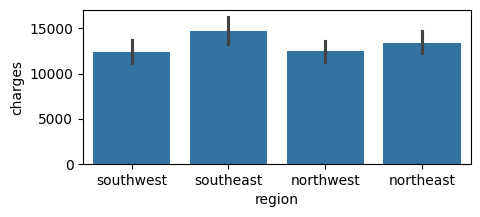

In [ ]:
# region
# region, charges

plt.figure(figsize=(5,2))
sns.barplot(data,x='region',y='charges')
plt.show()

In [ ]:
#
data.loc[:,'Region']=data.loc[:,'region'].map({'southwest':0,'northwest':1,'northeast':2,'southeast':3})

In [ ]:
data.drop(columns='region',inplace=True)

# Scaling
If numerical columns has lot of variations among values then we use scaling just to bring all values to a same scale.
- Min max scaler
- Standard Scaler

# **Min max scaler**

It will normalize all values in numerical columns into a range of 0 to 1.

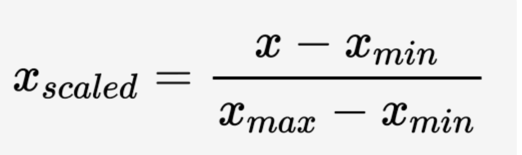

In [ ]:
df = data.copy()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[['age']]= scaler.fit_transform(df[['age']])
df[['bmi']]= scaler.fit_transform(df[['bmi']])

## **Standard Scaler**

It transforms all the values in a column such that mean = 0 and std = 1.

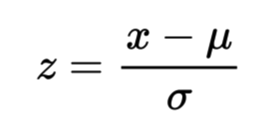

In [ ]:
df1 = data.copy()

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df1[['age']]= scaler.fit_transform(df1[['age']])
df1[['bmi']]=scaler.fit_transform(df1[['bmi']])

## Log Transformation
In regression model assume target variable to be normally distributed.Log transformation is used to convert skewed data into normal.


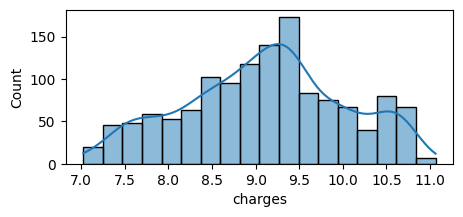

In [ ]:
# charges
plt.figure(figsize=(5,2))
sns.histplot(df,x='charges',kde=True)
plt.show()

In [ ]:
df.loc[:,'charges']=np.log(df.loc[:,'charges'])

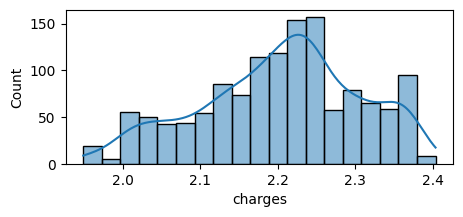

In [ ]:
plt.figure(figsize=(5,2))
sns.histplot(df,x='charges',kde=True)
plt.show()

# Feature Engineering
* Selecting features
* drop columns
* create columns

In [ ]:
df

,age,bmi,children,charges,Smoker,sex_female,sex_male,Region
0,0.021739,0.371847,0,2.275643,1,1,0,0
1,0.000000,0.554656,1,2.008657,0,0,1,3
2,0.217391,0.530676,3,2.128296,0,0,1,3
3,0.326087,0.210059,0,2.302394,0,0,1,1
4,0.304348,0.402367,0,2.111448,0,0,1,1
...,...,...,...,...,...,...,...,...
1333,0.695652,0.467456,3,2.226639,0,0,1,1
1334,0.000000,0.497041,0,2.041081,0,1,0,2
1335,0.000000,0.650576,0,2.000971,0,1,0,3
1336,0.065217,0.306447,0,2.028788,0,1,0,0


## **Split data for x and y**

In [ ]:
x = df.drop(columns='charges')
y= df['charges']

## **Split data for training as well testing**

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

## **Linear Regression**

In [ ]:
# import the model
from sklearn.linear_model import LinearRegression
# initialise the model
model = LinearRegression()
# train model : x_train,y_train
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
# make predictions
y_pred = model.predict(x_test)

In [ ]:
# Slope
print(model.coef_)

[ 0.18182086  0.03748881  0.0121023   0.16468536  0.00458145 -0.00458145
 -0.00041216]


In [ ]:
# intercept
print(model.intercept_)

2.0562379430295534


## Evaluate the Linear Regression

# Mean Squared error

In [ ]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,mean_absolute_percentage_error

In [ ]:
# y_test,y_pred
mean_squared_error(y_test,y_pred)

0.0021898467208862275

# Mean absolute error

In [ ]:
mean_absolute_error(y_test,y_pred)

0.030512793640374763

# Root Mean squared Error

In [ ]:
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(0.04679579811143547)

# Mean Absolute Percentage Error

In [ ]:
mean_absolute_percentage_error(y_test,y_pred)

0.013908652060793562

# R2 score

# Adjusted r2 score